## D Vamsidhar - 24/12/2025
### Off Policy Temporal Difference Method

In [1]:
# importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from envs import Maze
from utils import plot_policy, plot_action_values, test_agent
import warnings

warnings.filterwarnings('ignore')

In [2]:
env = Maze()

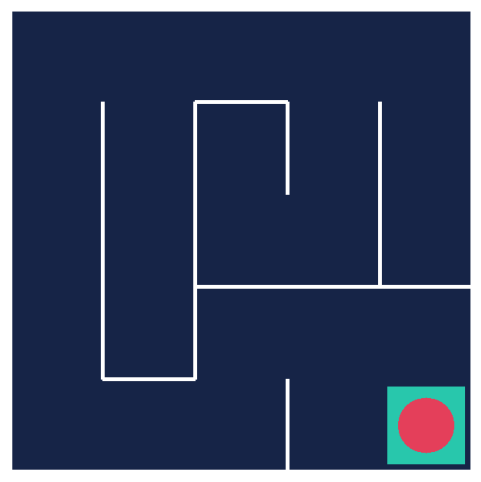

In [3]:
frame = env.render(mode='rgb_array')
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(frame)

In [4]:
print(f"Observation space shape: {env.observation_space.nvec}")
print(f"Action space: {env.action_space.n}")

Observation space shape: [5 5]
Action space: 4


In [5]:
action_values = np.zeros(shape=(5, 5, 4))

In [6]:
def target_policy(state):
    av = action_values[state]
    return np.random.choice(np.flatnonzero(av == av.max()))

In [7]:
def exploratory_policy(state):
    return np.random.randint(4)

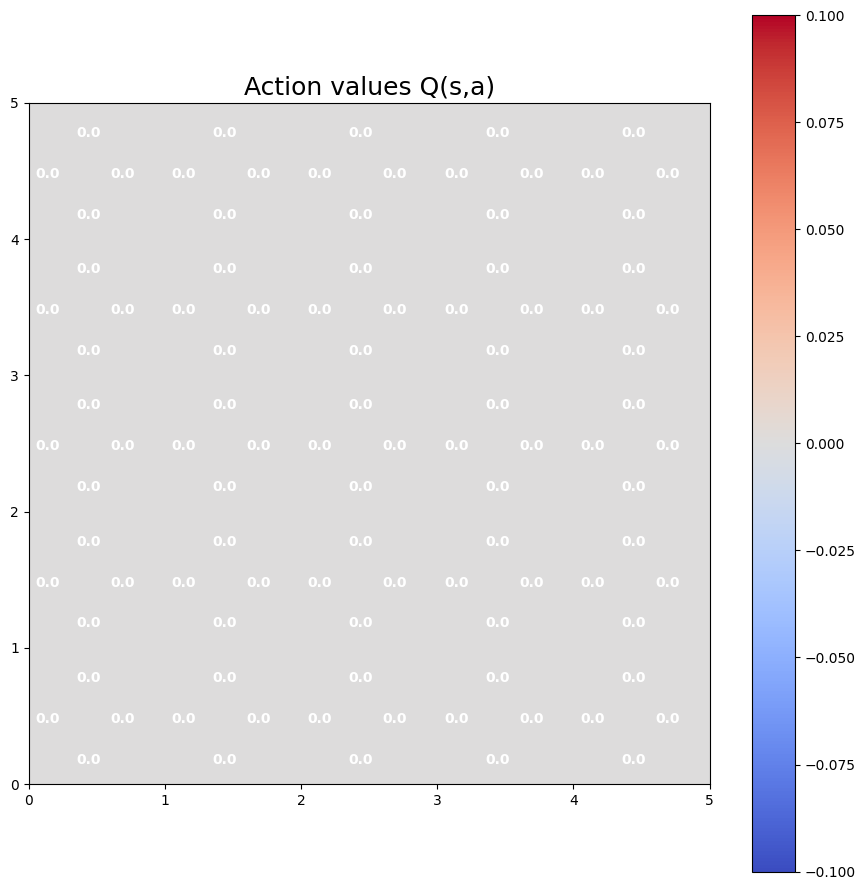

In [8]:
plot_action_values(action_values)

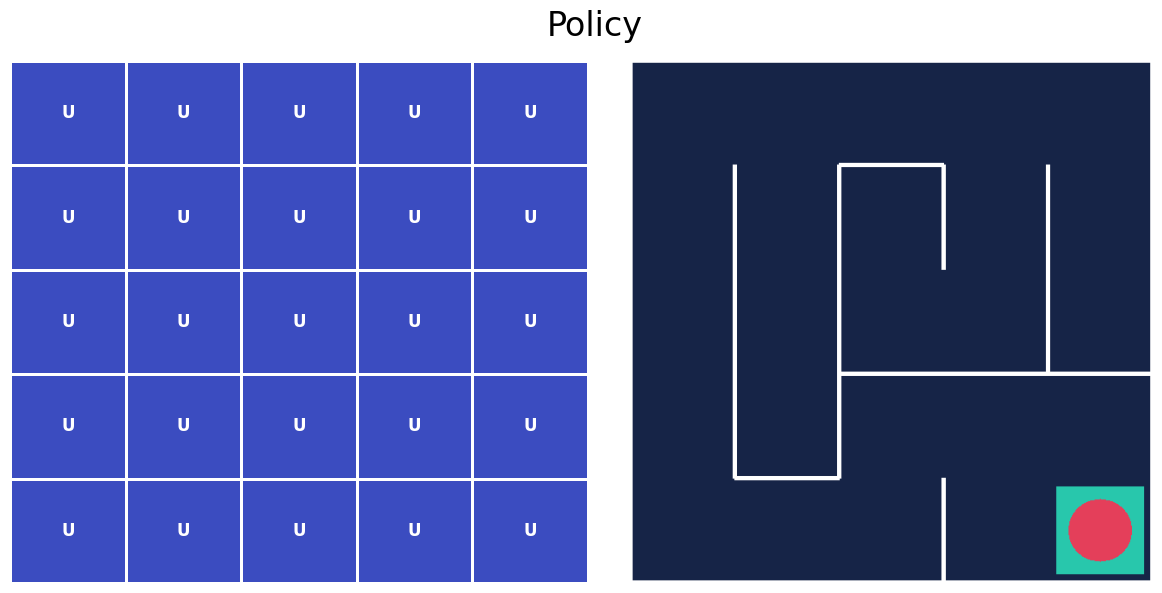

In [9]:
plot_policy(action_values, env.render(mode='rgb_array'))

In [10]:
def q_learning(action_values, exploratory_policy, target_policy, episodes, alpha=0.1, gamma=0.99):

    for episodes in range(1, episodes + 1):
        state = env.reset()
        done = False

        while not done:
            action = exploratory_policy(state)
            next_state, reward, done, _ = env.step(action)
            next_action = target_policy(next_state)

            qsa = action_values[state][action]
            next_qsa = action_values[next_state][next_action]
            action_values[state][action] = qsa + alpha * (reward + gamma * next_qsa - qsa)

            state = next_state

In [11]:
q_learning(action_values, exploratory_policy, target_policy, episodes=20)

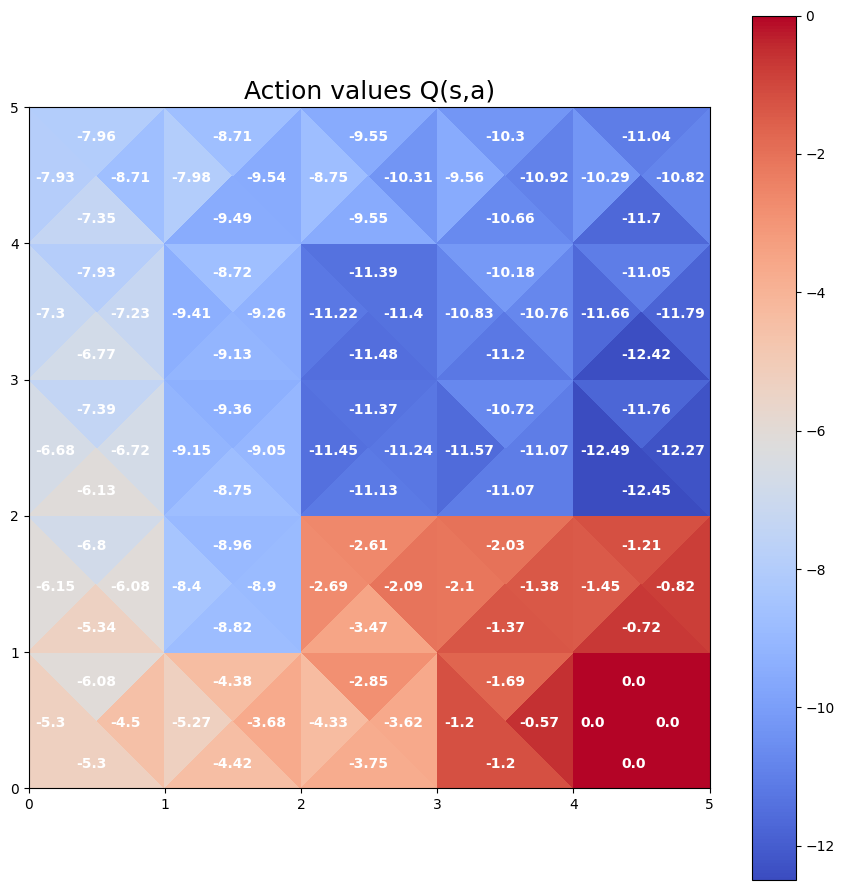

In [12]:
plot_action_values(action_values)

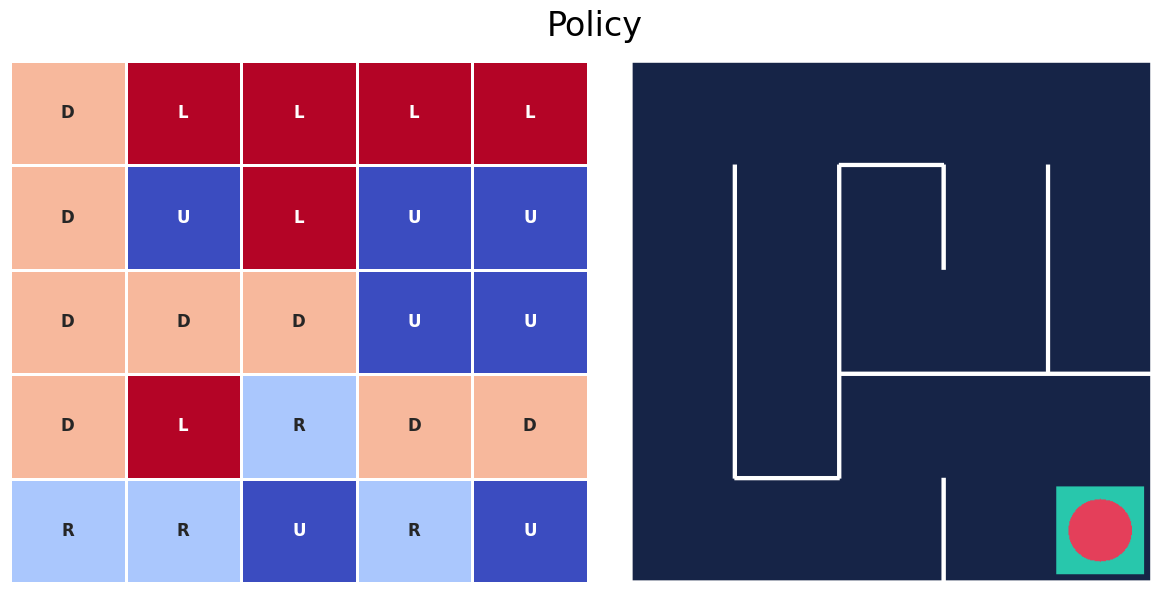

In [13]:
plot_policy(action_values, env.render(mode='rgb_array'))

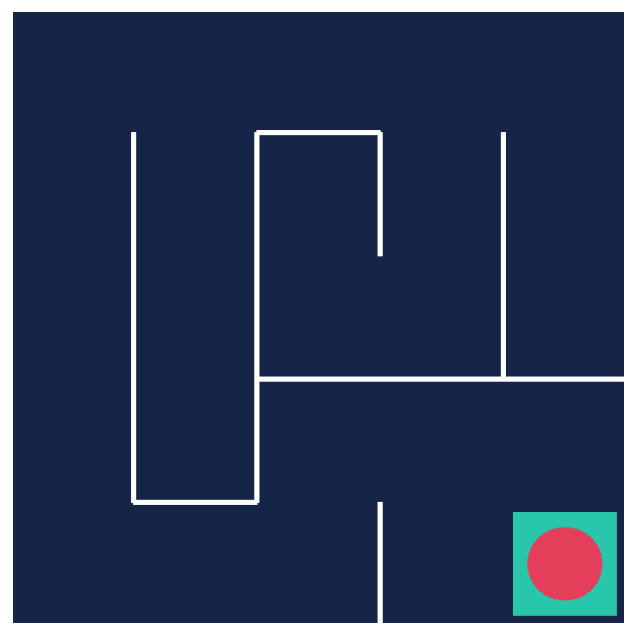

In [15]:
test_agent(env, target_policy, episodes=20)